## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline



## Read Data

We will need the meteorological data for all 6 stations

In [2]:
# Read datasets and set the index to be the date
df1 = pd.read_csv('../datasets/TX-Data/met_station/met_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('../datasets/TX-Data/met_station/met_2.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('../datasets/TX-Data/met_station/met_3.dat', sep=",", parse_dates=["Date"], index_col="Date")
df4 = pd.read_csv('../datasets/TX-Data/met_station/met_4.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('../datasets/TX-Data/met_station/met_5.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('../datasets/TX-Data/met_station/met_6.dat', sep=",", parse_dates=["Date"], index_col="Date")


**Date:** Synchronized time stamps (CST)

**Tair:** air temperature (deg C)

**RH:** relative humidity (percentage): https://en.wikipedia.org/wiki/Humidity

**Wind speed:** meters/second

**Wind direction:** Degree

**Srad:** solar radiation (W/m^2) https://en.wikipedia.org/wiki/Solar_irradiance

In [3]:
# save dataframes into list
DF = [df1, df2, df3, df4, df5, df6]

Remove spaces in the column names

In [4]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [5]:
# remove column name spaces of each DataFrame 
for df in DF:
    remove_spaces(df)

# Visualization of Annual Station Air Temperature

We will only use Air Temperature data. For quick access, we will save the Air Temperature data of each Station into one Dataframe. `select_feature()` will take in the list of DataFrames `DF`, and the Air Temperature feature name `"Tair"`. This creates the Air Temperature-only dataframe.

In [6]:
# Selects a feature from the data. Creates df with Stations as columns.
# Takes in list of dataframes and the selected feature as a string. 
def select_feature(DF, feature):
    df_feature = pd.concat(DF, axis=1)[feature]
    df_feature.columns = [str(f"Station{i}") for i in range(1, len(DF)+1)]
    return df_feature

In [7]:
# create df with only Air temp data of each Station
df_Tair = select_feature(DF, "Tair")
df_Tair

,Station1,Station2,Station3,Station4,Station5,Station6
Date,,,,,,
2014-10-01 00:00:00,22.13,NaN,NaN,NaN,NaN,NaN
2014-10-01 01:00:00,21.68,NaN,NaN,NaN,NaN,NaN
2014-10-01 02:00:00,22.21,NaN,NaN,NaN,NaN,NaN
2014-10-01 03:00:00,22.41,NaN,NaN,NaN,NaN,NaN
2014-10-01 04:00:00,22.30,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-08-31 20:00:00,29.10,NaN,28.24,29.94,29.81,31.41
2021-08-31 21:00:00,28.07,NaN,26.14,28.88,28.51,30.31
2021-08-31 22:00:00,27.73,NaN,24.94,28.19,27.77,29.99


For every year, we plot all stations' data. `plot_feature()` takes in a DataFrame created by `select_feature()` and a string to be used as plot titles. For every year, `plot_feature()` plots the overlapped data of the stations, and a subplot for each individual station.

In [8]:
# Plots visual comparison of all stations' annual Air Temp data. 
# Takes in df output of select_feature() and a string to be used as title
def plot_feature(df_feature, title):
    years = [str(yr) for yr in range(2015, 2022)]

    for yr in years:        
        df_yr = df_feature[yr].resample('D').mean()
        
        df_yr.plot(figsize=(12,6), title=f"{yr} {title}")
        df_yr.plot(figsize=(12,6), subplots=True, layout=(3,2))

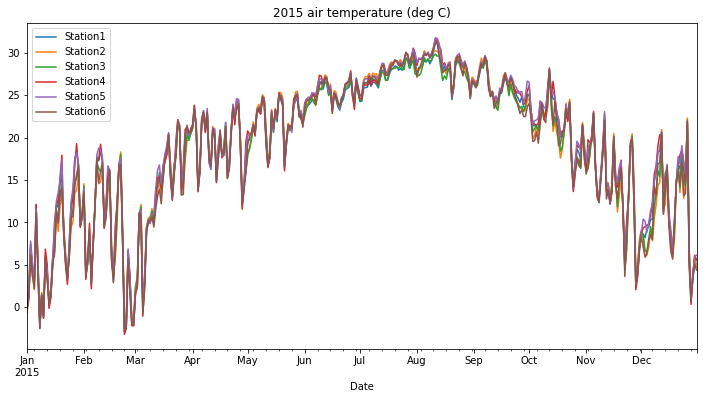

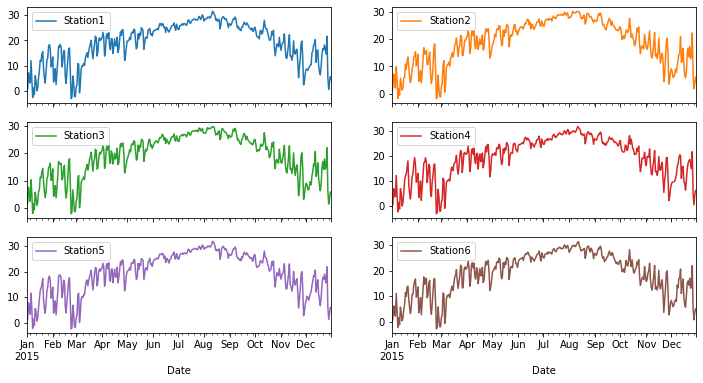

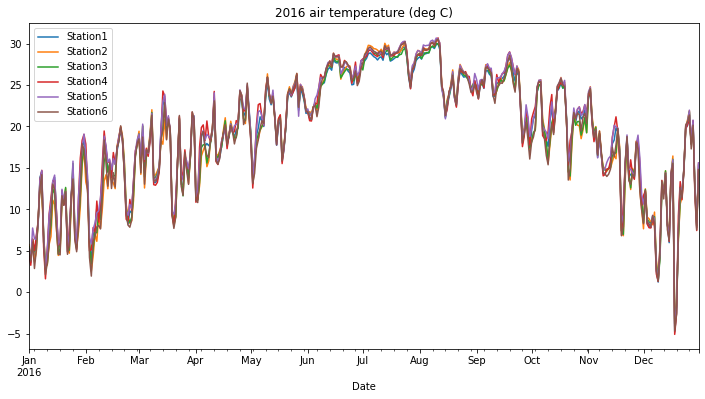

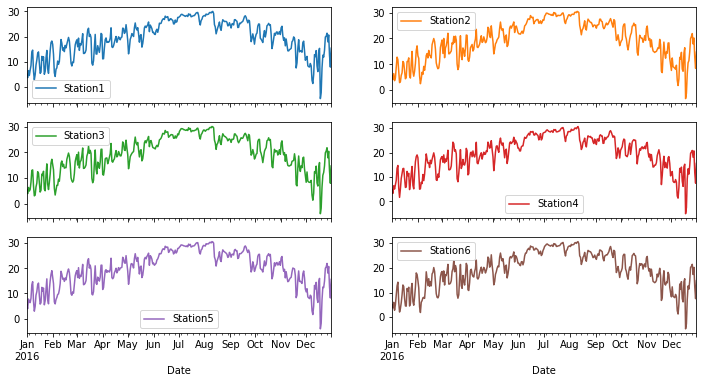

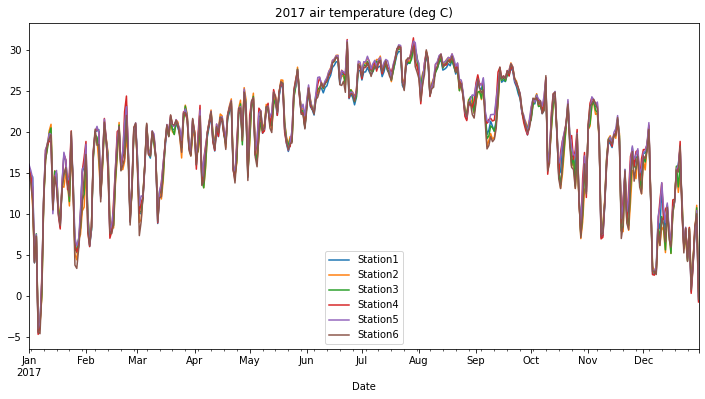

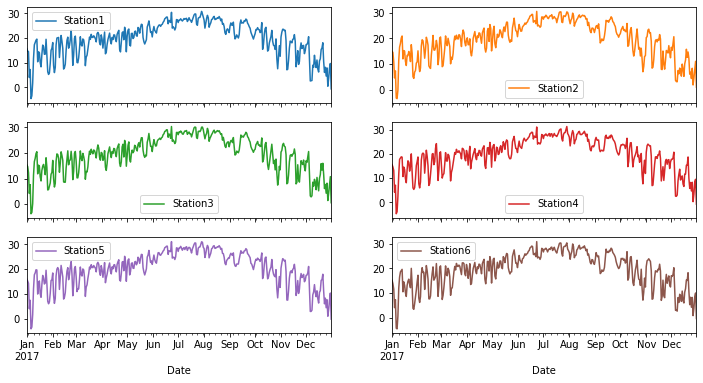

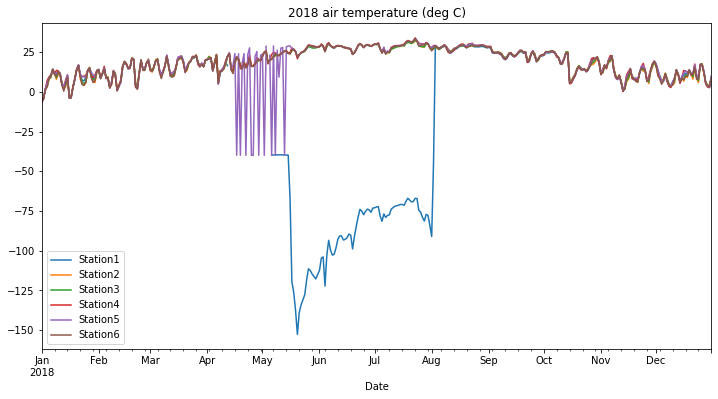

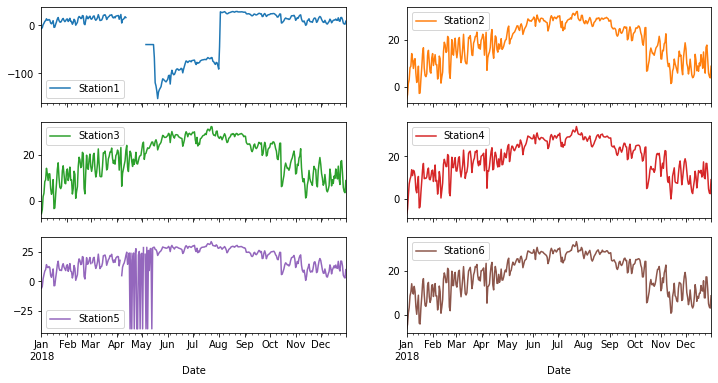

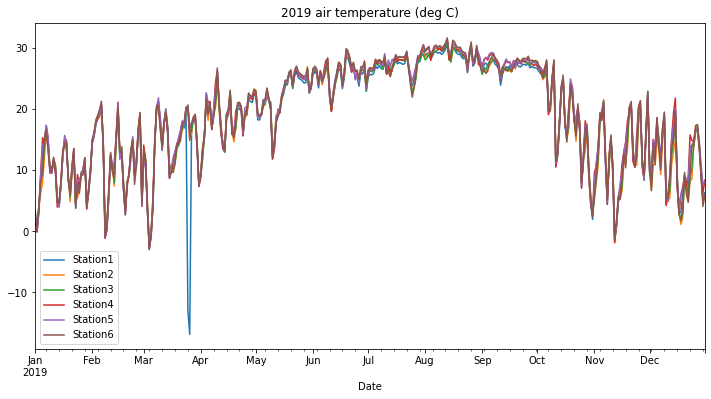

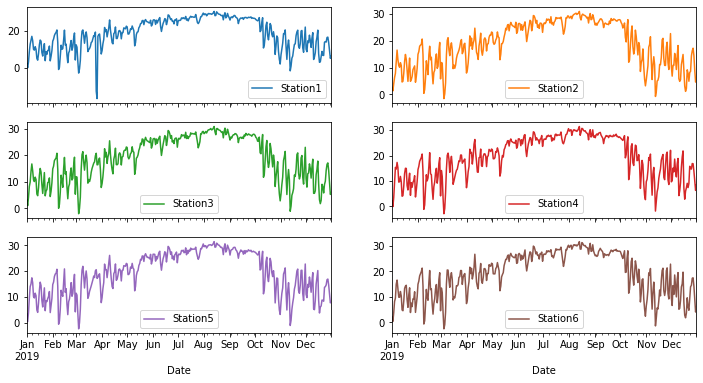

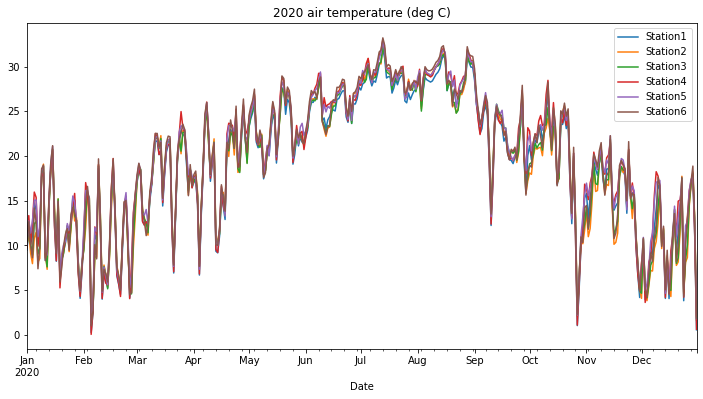

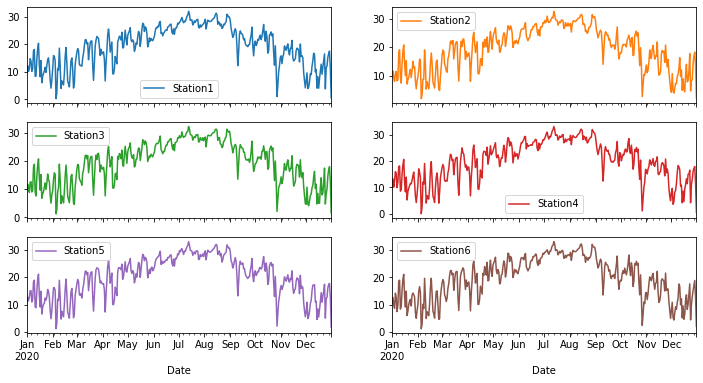

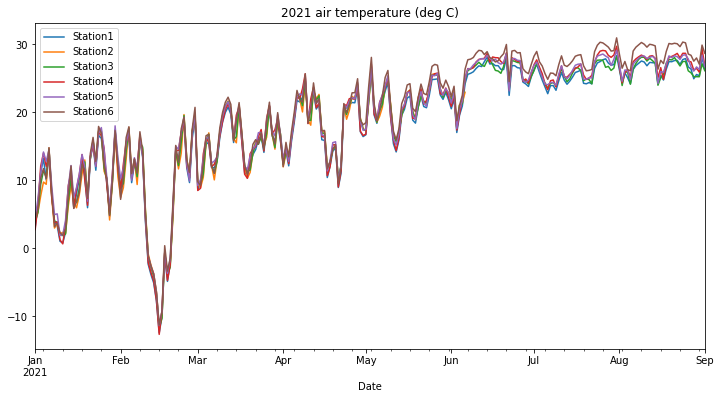

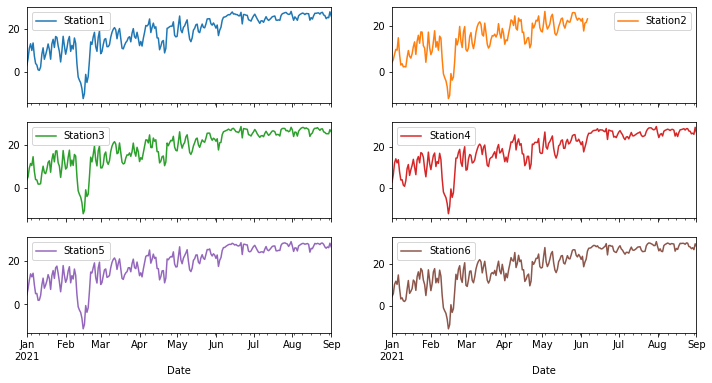

In [9]:
# For each year, plot the Air Temperature Data of all stations
plot_feature(df_Tair, "air temperature (deg C)")

## Summary of Visual Comparisons:

Annual Air Temperature was very similar accross stations. Some anomalies were detected:
#### 2018: Station 1 and 5 have abnormally low values.  Station 1 and 5 April data missing.
#### 2019: Station 1 March data is inconsistent with other stations. 
#### 2021: Station 2 data missing from Jun to Sep.
Note:\
2021 data ends at September \
2021 February Winter Storm Uri hit Texas.



# Cleaning Air Temperature Data

Since data was very similar across stations, Annual means are a good approximations.

# 2018

Stations 1 and 5 had abnormal values and some missing data in 2018. Since we will use the mean to clean these datasets, we need to exclude Station 1 and Station 5 from the 2018 mean. The 2018 mean is recorded in `df_2018_Tair_mean`.

In [10]:
# Exlude Station 1 and 5 Air Temp data from mean
df_2018_Tair_mean = df_Tair.drop(["Station1", "Station5"], axis=1).mean(axis=1)

### Station 5 cleaning

First, we plot the time frame we will clean, *2018 Apr-May*, and compare it to the 2018 mean data.

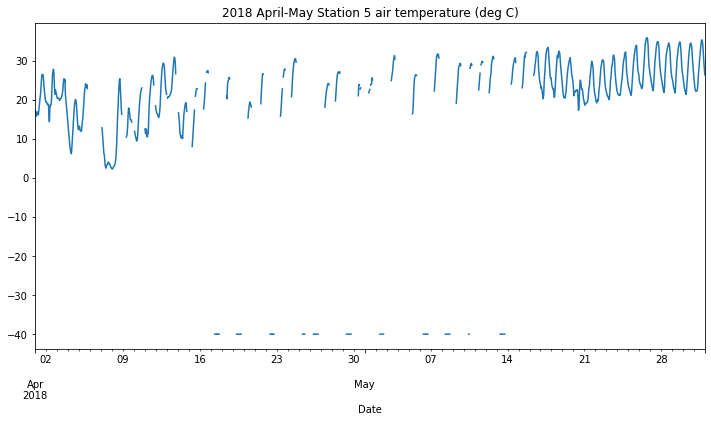

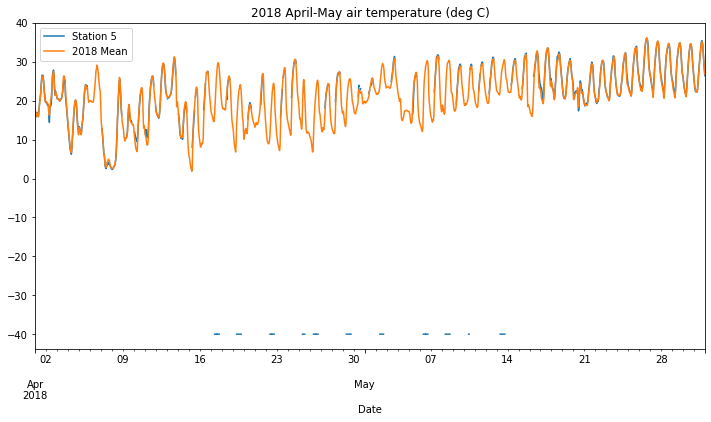

In [11]:
# Vizualize Station 5 Apr - May anomaly.
df_Tair["2018-4":"2018-5"].Station5.plot(figsize=(12,6), label=f"Station 5")
plt.title("2018 April-May Station 5 air temperature (deg C)")
plt.show()

# Compare Station 5 and mean
df_Tair["2018-4":"2018-5"].Station5.plot(figsize=(12,6), label=f"Station 5")
df_2018_Tair_mean["2018-4":"2018-5"].plot(figsize=(12,6), label=f"2018 Mean")
plt.legend()
plt.title("2018 April-May air temperature (deg C)")
plt.show()


The data that is not missing is consistent with the mean - except for the abnormal lows near -40 C.\
Therefore, we will only use the mean on the missing and abnormally low data points.

`mean_imputation()` takes the data to be cleaned and the mean data. The function outputs the indices that were imputed. The NaN values in Station 5 data will be replaced with the 2018 mean data. 

In [12]:
# imputes missing values with mean
def mean_imputation (df, df_mean):
    to_impute = df[df.isna() == True].index
    df[to_impute] = df_mean[to_impute]
    
    # document imputed indices
    return to_impute

`mean_replace_low()` takes the data to be cleaned, the mean data, and a lower limit value. The function outputs the indices that were replaced. Values lower than the set limit in Station 5 data will be replaced with the 2018 mean data. 

In [13]:
# replaces values below given limit with mean
def mean_replace_low (df, df_mean, lim):
    to_replace = df[df < lim].index
    df[to_replace] = df_mean[to_replace]
    
    # document replaced indices
    return to_replace

 Only the specific 2018 April to May time frame should be input in `mean_imputation()` and `mean_replace_low()`. \
 i.e. here we input `df_Tair["2018-4":"2018-5"].Station5`

In [14]:
# Clean Data
# Record changed indices
S5_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-5"].Station5, df_2018_Tair_mean)
S5_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-5"].Station5, df_2018_Tair_mean, -20)

Here we plot the cleaned result for 2018 Station 5

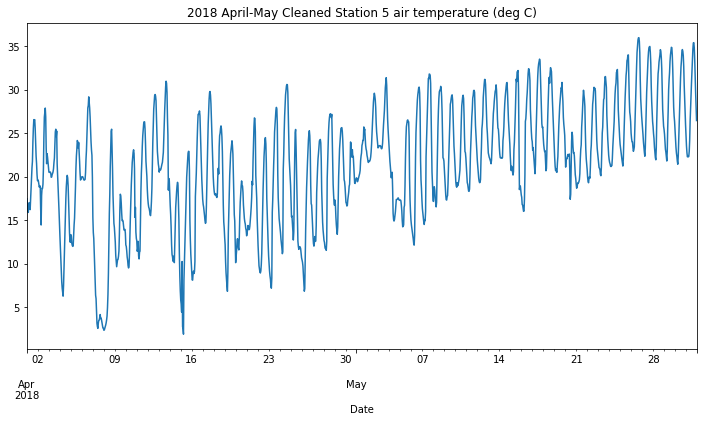

In [15]:
# Vizualize Cleaned Station 5 Apr - May.
df_Tair["2018-4":"2018-5"].Station5.plot(figsize=(12,6), label=f"Station 5")
plt.title("2018 April-May Cleaned Station 5 air temperature (deg C)")
plt.show()

### Station 1 cleaning

Here, we repeat the same process for the 2018 Apr-Aug Station 1 data using `mean_imputation()` and `mean_replace_low()`.

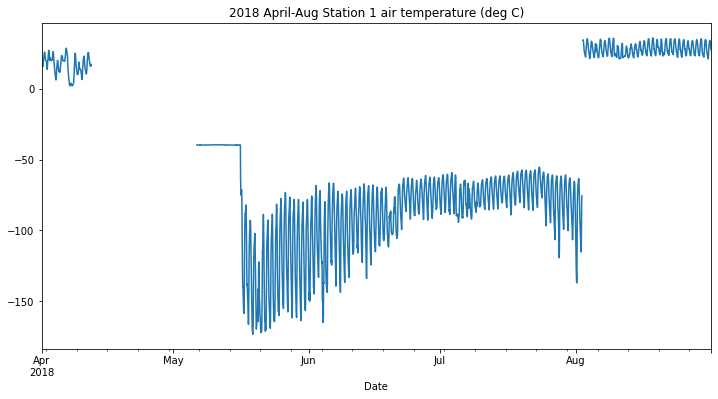

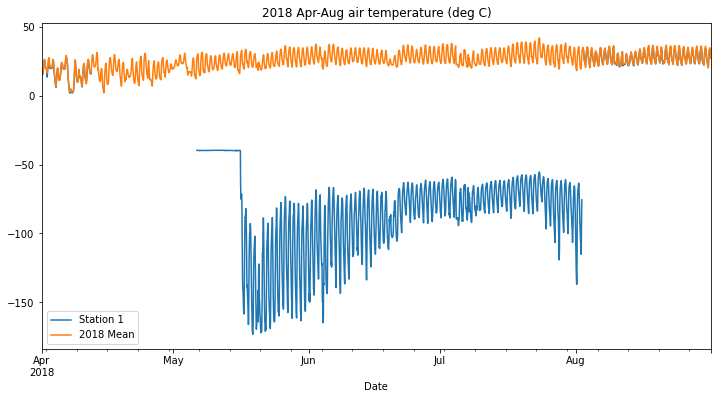

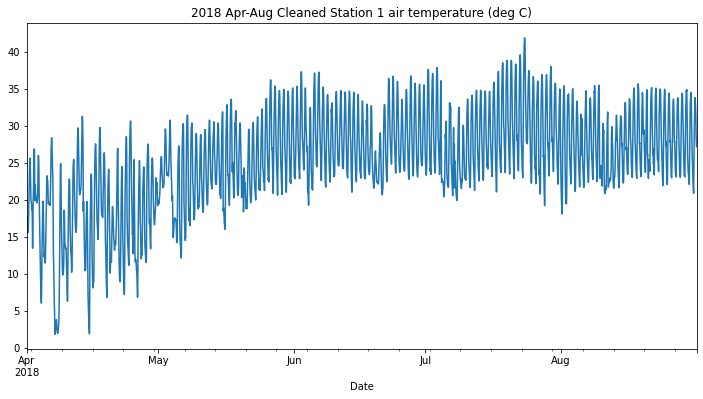

In [16]:
# Vizualize Station 1 Apr - Aug anomaly.
df_Tair["2018-4":"2018-8"].Station1.plot(figsize=(12,6), label=f"Station 1")
plt.title("2018 April-Aug Station 1 air temperature (deg C)")
plt.show()

# Compare Station 1 and mean
df_Tair["2018-4":"2018-8"].Station1.plot(figsize=(12,6), label=f"Station 1")
df_2018_Tair_mean["2018-4":"2018-8"].plot(figsize=(12,6), label=f"2018 Mean")
plt.legend()
plt.title("2018 Apr-Aug air temperature (deg C)")
plt.show()


# Clean Data
# Record changed indices
S1_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-8"].Station1, df_2018_Tair_mean)
S1_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-8"].Station1, df_2018_Tair_mean, -10)

# Vizualize Cleaned Station 1 Apr - Aug.
df_Tair["2018-4":"2018-8"].Station1.plot(figsize=(12,6), label=f"Station 1")
plt.title("2018 Apr-Aug Cleaned Station 1 air temperature (deg C)")
plt.show()

# 2019

Station 1 had abnormal values in 2019. Since we will use the mean to clean these datasets, we need to exclude Station 1 from the 2019 mean. The 2019 mean is recorded in `df_2019_Tair_mean`.

In [17]:
# Exlude Station 1 Air Temp data from mean
df_2019_Tair_mean = df_Tair.drop(["Station1"], axis=1).mean(axis=1)

We can continue to repeat the same process we used to clean the 2018 data. In this case there are no missing values, so we only need to use `mean_replace_low()`

### Station 1 cleaning

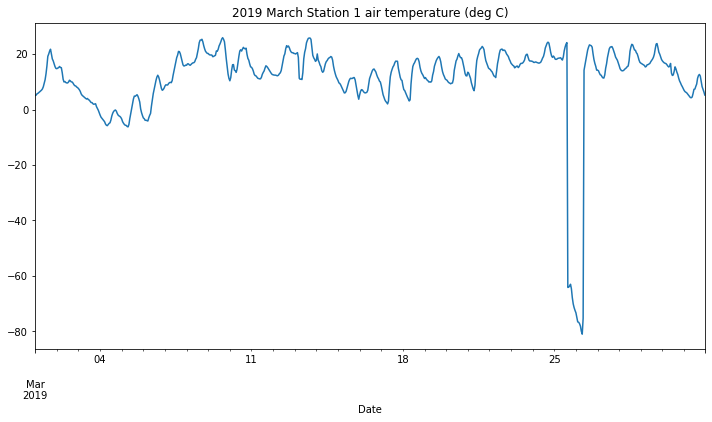

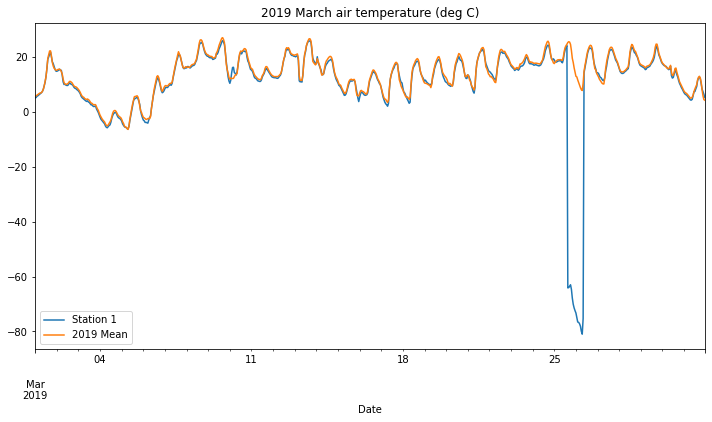

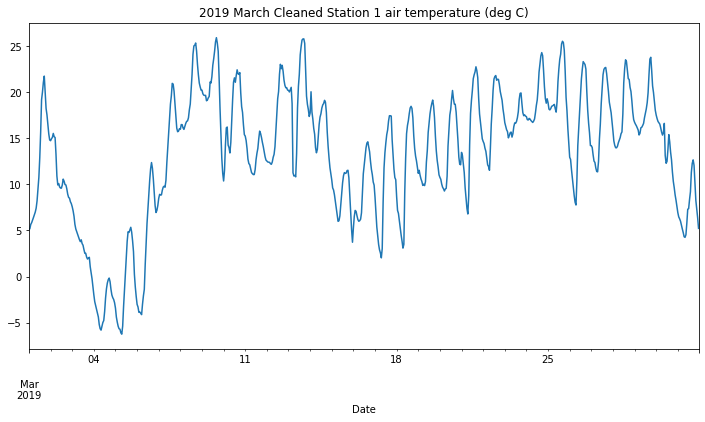

In [18]:
# Vizualize Station 1 March anomaly.
df_Tair["2019-3"].Station1.plot(figsize=(12,6), label=f"Station 1")
plt.title("2019 March Station 1 air temperature (deg C)")
plt.show()

# Compare Station 1 and mean
df_Tair["2019-3"].Station1.plot(figsize=(12,6), label=f"Station 1")
df_2019_Tair_mean["2019-3"].plot(figsize=(12,6), label=f"2019 Mean")
plt.legend()
plt.title("2019 March air temperature (deg C)")
plt.show()


# Clean Data
# Record changed indices
S1_2019_replaced = mean_replace_low (df_Tair["2019-3"].Station1, df_2019_Tair_mean, -20)

# Vizualize Cleaned Station 1 March.
df_Tair["2019-3"].Station1.plot(figsize=(12,6), label=f"Station 1")
plt.title("2019 March Cleaned Station 1 air temperature (deg C)")
plt.show()

# 2021

Station 2 had missing values in 2021. We exlude Station 2 from the 2021 mean and record it in `df_2021_Tair_mean`

In [19]:
# Exlude Station 2 Air Temp data from mean
df_2021_Tair_mean = df_Tair.drop(["Station2"], axis=1).mean(axis=1)

We can continue to repeat the same cleaning process. In this case there are only missing values, so we only need to use `mean_imputation()`

### Station 2 cleaning

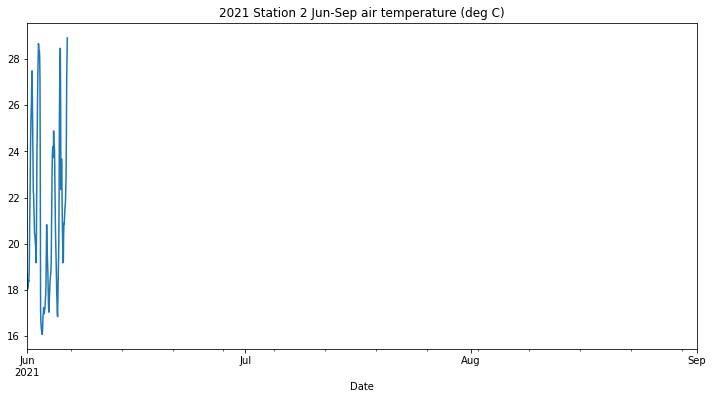

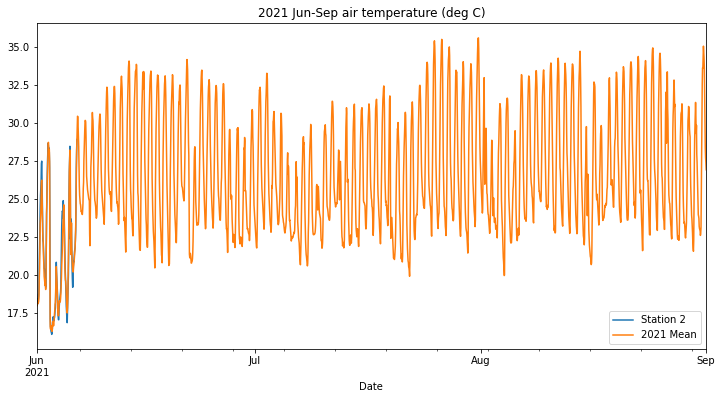

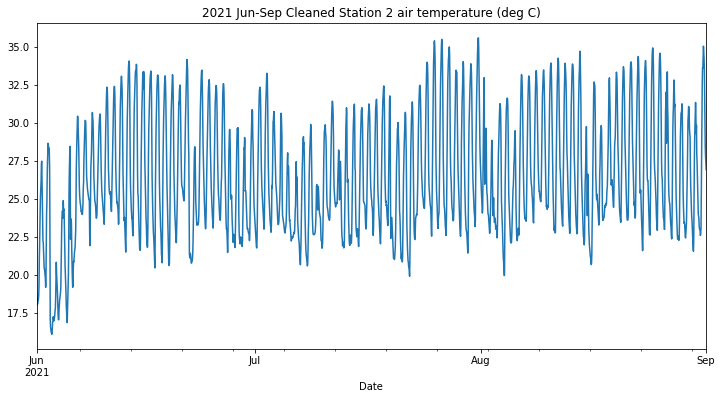

In [20]:
# Vizualize Station 2.
df_Tair["2021-6":"2021-9"].Station2.plot(figsize=(12,6), label=f"Station 2")
plt.title("2021 Station 2 Jun-Sep air temperature (deg C)")
plt.show()

# Compare Station 2 and mean
df_Tair["2021-6":"2021-9"].Station2.plot(figsize=(12,6), label=f"Station 2")
df_2021_Tair_mean["2021-6":"2021-9"].plot(figsize=(12,6), label=f"2021 Mean")
plt.legend()
plt.title("2021 Jun-Sep air temperature (deg C)")
plt.show()



# Clean Data
# Record changed indices
S2_2021_imputed = mean_imputation (df_Tair["2021-6":"2021-9"].Station2, df_2021_Tair_mean)

# Vizualize Cleaned Station 2.
df_Tair["2021-6":"2021-9"].Station2.plot(figsize=(12,6), label=f"Station 2")
plt.title("2021 Jun-Sep Cleaned Station 2 air temperature (deg C)")
plt.show()

### Document Changes

Data Cleaning is done. Changed indices of Sation 1 are saved in`S1_2018_replaced`, `S1_2018_imputed`, and `S1_2019_replaced`. Changed indices of Station 2 are saved in `S2_2021_imputed`. Changed indices of Station 5 are saved in `S5_2018_imputed` and `S5_2018_replaced`.

We combine and sort the indices for each Station using `Index.Union()` method. 

In [21]:
# Concatenate and sort changed indices for each Station
S1_changed_idx = (S1_2018_replaced.union(S1_2018_imputed)).union(S1_2019_replaced)
S2_changed_idx = S2_2021_imputed
S5_changed_idx = S5_2018_imputed.union(S5_2018_replaced)

In [22]:
# print results
print("Indices Changed during Cleaning:\n")
print("Station 1")
print(S1_changed_idx, "\n")
print("Station 2")
print(S2_changed_idx, "\n")
print("Station 5")
print(S5_changed_idx)

Indices Changed during Cleaning:

Station 1
DatetimeIndex(['2018-04-12 09:00:00', '2018-04-12 10:00:00',
               '2018-04-12 11:00:00', '2018-04-12 12:00:00',
               '2018-04-12 13:00:00', '2018-04-12 14:00:00',
               '2018-04-12 15:00:00', '2018-04-12 16:00:00',
               '2018-04-12 17:00:00', '2018-04-12 18:00:00',
               ...
               '2019-03-25 23:00:00', '2019-03-26 00:00:00',
               '2019-03-26 01:00:00', '2019-03-26 02:00:00',
               '2019-03-26 03:00:00', '2019-03-26 04:00:00',
               '2019-03-26 05:00:00', '2019-03-26 06:00:00',
               '2019-03-26 07:00:00', '2019-03-26 08:00:00'],
              dtype='datetime64[ns]', name='Date', length=2713, freq=None) 

Station 2
DatetimeIndex(['2021-06-06 14:00:00', '2021-06-06 15:00:00',
               '2021-06-06 16:00:00', '2021-06-06 17:00:00',
               '2021-06-06 18:00:00', '2021-06-06 19:00:00',
               '2021-06-06 20:00:00', '2021-06-06 21:00:

Data from Sations 3, 4, and 6 were left unchanged

# Visualization of Results

The cleaned data is saved in `df_Tair`. We can use the `plot_feature()` function from earlier to display the new data

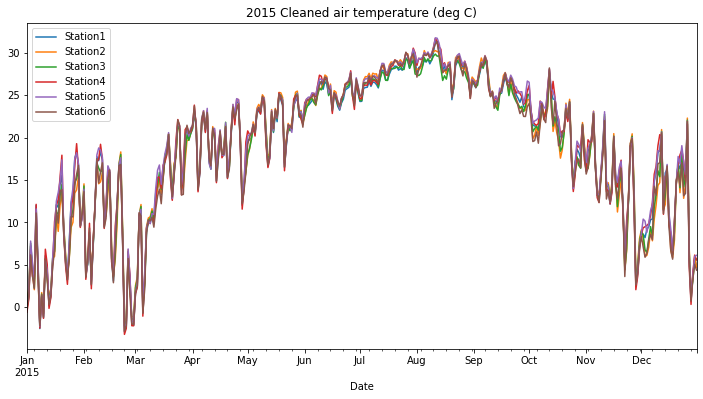

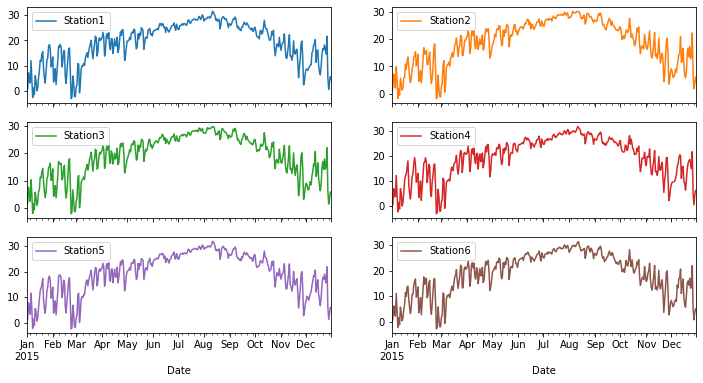

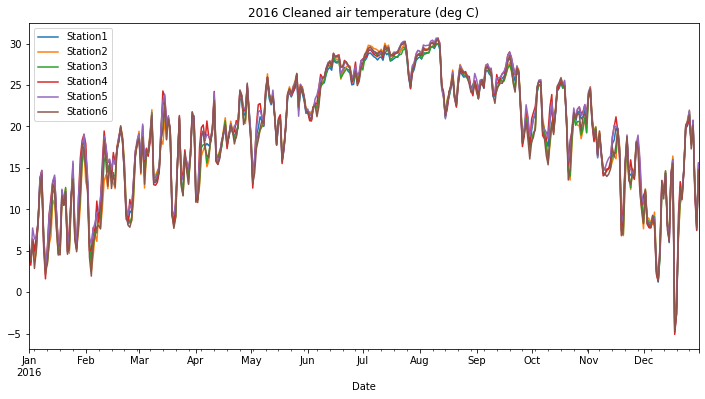

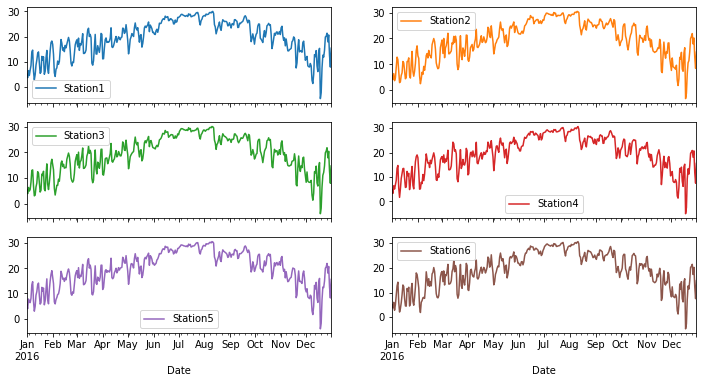

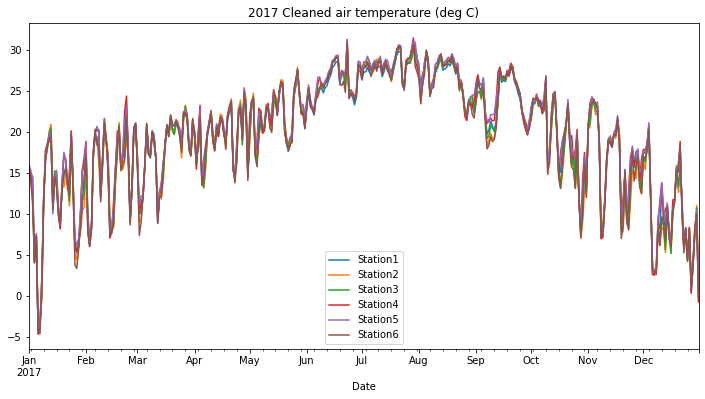

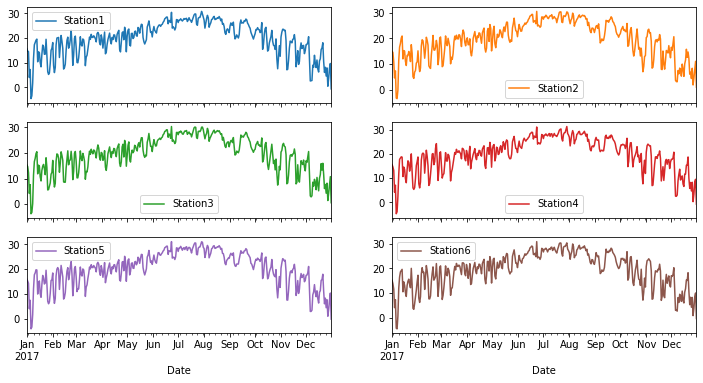

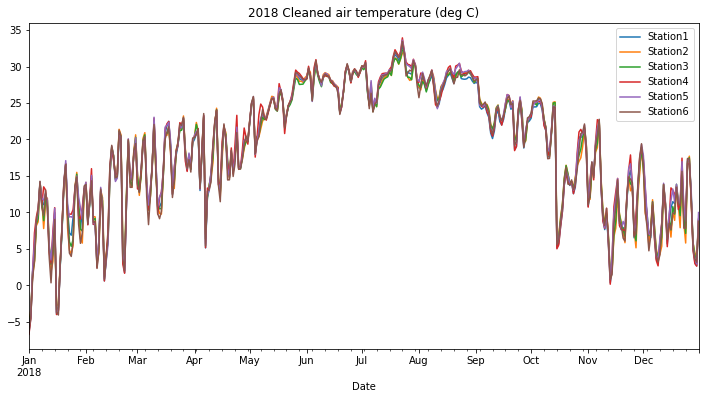

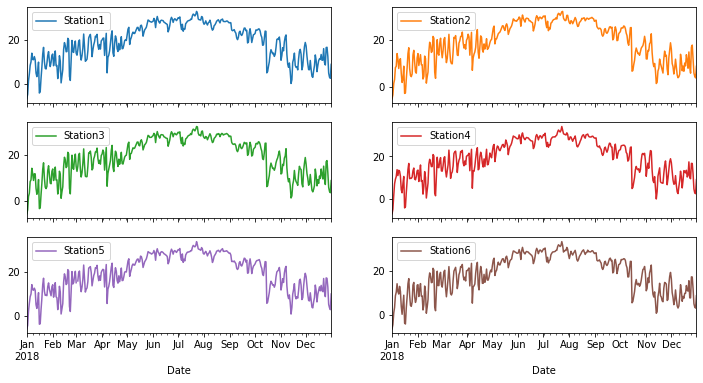

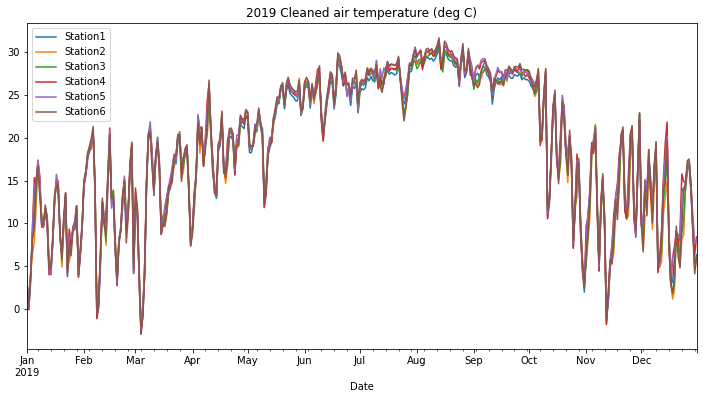

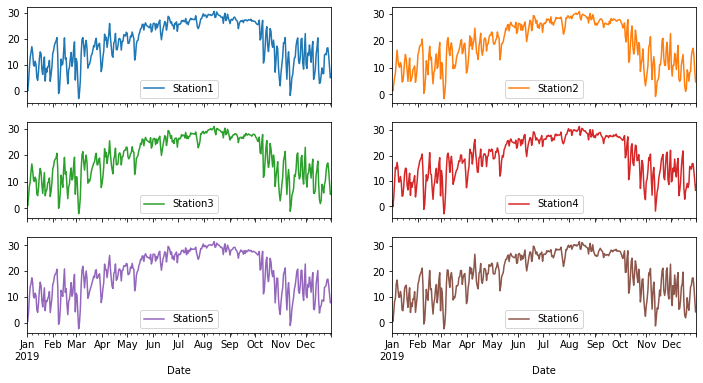

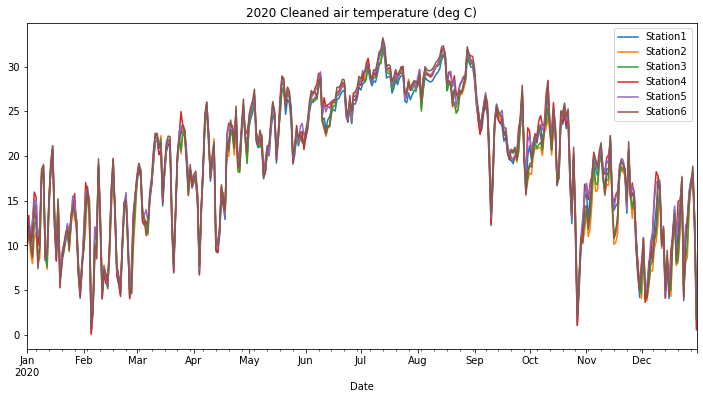

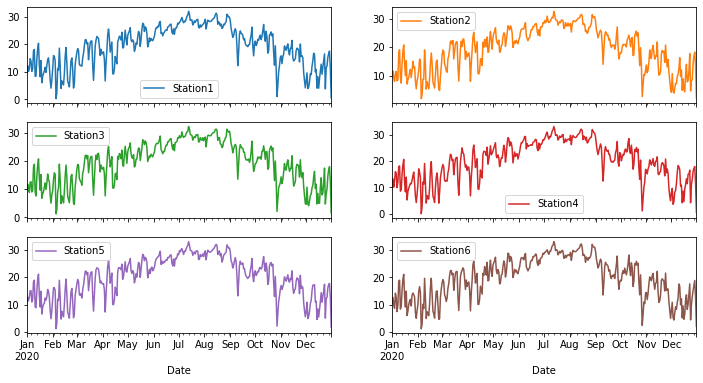

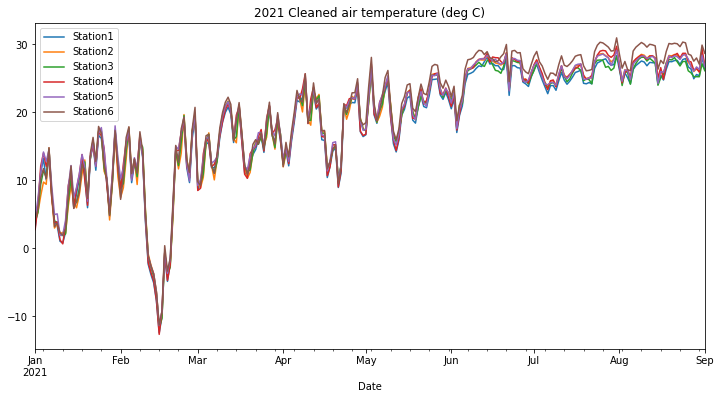

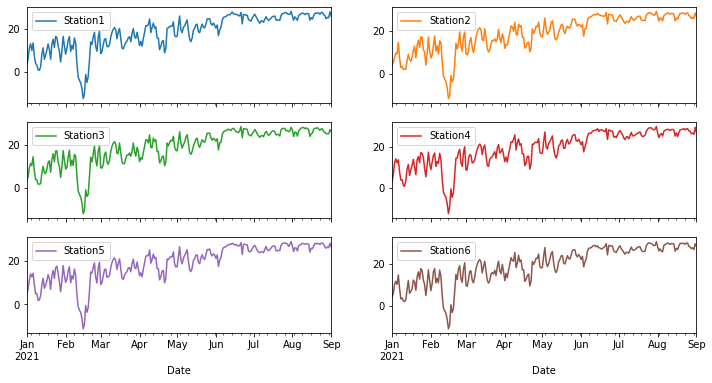

In [23]:
# Plot cleaned data
plot_feature(df_Tair, "Cleaned air temperature (deg C)")

### Save Clean Data as .csv

In [24]:
#df_Tair.to_csv("met_Tair_cleaned.csv")